In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# ----------------------------
# 1) Load data + dictionaries
# ----------------------------
df = pd.read_csv("/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/nri_hpi_data_full.csv", low_memory=False)

# Attach NRI dictionary (optional)
try:
    nri_dict = pd.read_csv("/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/NRIDataDictionary.csv", low_memory=False)
    if nri_dict.empty:
        nri_dict = None
except Exception:
    nri_dict = None

# HPI dictionary (used to EXCLUDE any HPI columns from predictors)
try:
    hpi_dict = pd.read_excel("/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/hpi_dictionary.xlsx")
    if hpi_dict.empty:
        hpi_dict = None
except Exception:
    hpi_dict = None

In [7]:
# ----------------------------
# 2) Target column (hpi_change)
# ----------------------------
target_col = next((c for c in df.columns if c.lower() == "hpi_change"), None)
if target_col is None:
    for c in df.columns:
        if re.fullmatch(r"hpi[_\s]?change", c, flags=re.IGNORECASE):
            target_col = c
            break
if target_col is None:
    raise KeyError("Couldn't find a target column named 'hpi_change' (case-insensitive).")

y_all = pd.to_numeric(df[target_col], errors="coerce")


In [8]:
# ----------------------------
# 3) Build the set of HPI columns to exclude
# ----------------------------
hpi_vars_lower = set()
if isinstance(hpi_dict, pd.DataFrame):
    name_col = None
    for c in hpi_dict.columns:
        if re.search(r"(variable|field|column).*name", c, flags=re.IGNORECASE) or re.fullmatch(
            r"(variable|var|field|name|column)", c, flags=re.IGNORECASE
        ):
            name_col = c; break
    if name_col is None:
        name_col = hpi_dict.columns[0]
    try:
        hpi_vars_lower = set(hpi_dict[name_col].astype(str).str.strip().str.lower().tolist())
    except Exception:
        hpi_vars_lower = set()

In [9]:
# ----------------------------
# 4) Build NRI-only predictor set (numeric; quality filters)
# ----------------------------
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
predictor_cols = []
for c in numeric_cols:
    if c == target_col:
        continue
    if c.strip().lower() in hpi_vars_lower:   # exclude HPI columns
        continue
    if re.match(r"^unnamed:\s*\d+\s*$", c.strip(), flags=re.IGNORECASE):
        continue

    s = pd.to_numeric(df[c], errors="coerce")
    if s.isna().mean() > 0.40:      # drop high-missing
        continue
    if s.nunique(dropna=True) <= 1: # drop constants
        continue
    predictor_cols.append(c)

if not predictor_cols:
    raise RuntimeError("No usable NRI predictors after excluding HPI variables and filtering.")

# Keep rows where target is present
mask = y_all.notna()
y = y_all.loc[mask].astype(float)
X_raw = df.loc[mask, predictor_cols].apply(pd.to_numeric, errors="coerce").astype(np.float64)

# Median imputation (vectorized)
X_imp = X_raw.fillna(X_raw.median())

# Standardize predictors (mean=0, std=1) for OLS interpretability
X_std = (X_imp - X_imp.mean()) / X_imp.std(ddof=0)
X_std = X_std.replace([np.inf, -np.inf], 0.0).fillna(0.0)

In [10]:
# ----------------------------
# 5) FAST VIF pruning (matrix-based)
#    VIF for standardized X equals diag(inv(corr(X))).
#    We invert the correlation matrix once per iteration (O(p^3), but only once),
#    and drop the top-K worst offenders to reduce iterations.
# ----------------------------
MAX_VIF   = 10.0   # threshold
MIN_VARS  = 8      # keep at least this many
MAX_STEPS = 50     # safety
DROP_K    = 3      # drop up to this many worst VIFs per iteration
RIDGE     = 1e-6   # tiny ridge for numerical stability

kept_cols = list(X_std.columns)
dropped_records = []  # (variable, step_idx, vif_at_drop)

step = 0
while step < MAX_STEPS and len(kept_cols) > MIN_VARS:
    # Correlation matrix for the current set
    Xk = X_std[kept_cols].to_numpy()
    # Because X_std is standardized, cov == corr; compute robustly
    corr = np.corrcoef(Xk, rowvar=False)
    # Handle any NaNs (can arise with all-zeros edge cases after std)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    # Add tiny ridge to keep it invertible
    corr = corr + np.eye(corr.shape[0]) * RIDGE
    # Pseudo-inverse is robust; diag(inv(corr)) = VIF
    inv_corr = np.linalg.pinv(corr)
    vif_vals = np.diag(inv_corr)
    vif_series = pd.Series(vif_vals, index=kept_cols, name="VIF")

    # Any above threshold?
    exceed = vif_series[vif_series > MAX_VIF].sort_values(ascending=False)
    if exceed.empty or len(kept_cols) <= MIN_VARS:
        break

    # Drop up to DROP_K worst offenders this round, but never go below MIN_VARS
    can_drop = max(0, len(kept_cols) - MIN_VARS)
    k = min(DROP_K, len(exceed), can_drop)
    to_drop = exceed.head(k).index.tolist()
    for var in to_drop:
        dropped_records.append((var, step, float(vif_series[var])))
        kept_cols.remove(var)

    step += 1

# Final VIF for kept set (recompute once)
Xk = X_std[kept_cols].to_numpy()
corr = np.corrcoef(Xk, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
corr = corr + np.eye(corr.shape[0]) * RIDGE
inv_corr = np.linalg.pinv(corr)
final_vif_vals = np.diag(inv_corr)
final_vif = pd.DataFrame({"variable": kept_cols, "VIF": final_vif_vals}).sort_values("VIF", ascending=False).reset_index(drop=True)


In [11]:
# ----------------------------
# 6) Standardized OLS on the VIF-pruned set
# ----------------------------
X_ols = sm.add_constant(X_std[kept_cols], has_constant="add")
ols_res = sm.OLS(y.values, X_ols.values).fit()

params = pd.Series(ols_res.params, index=["const"] + kept_cols, name="coef_std")
tvals  = pd.Series(ols_res.tvalues, index=["const"] + kept_cols, name="t_stat")
pvals  = pd.Series(ols_res.pvalues, index=["const"] + kept_cols, name="p_value")

# Drop intercept for per-variable effects
params = params.drop(labels=["const"])
tvals  = tvals.drop(labels=["const"])
pvals  = pvals.drop(labels=["const"])

# Partial correlation magnitude (unique effect controlling others)
df_resid = float(ols_res.df_resid)
partial_r = np.sign(params) * np.sqrt((tvals**2) / (tvals**2 + df_resid))
effects = pd.concat(
    [
        params.rename("std_beta"),
        tvals,
        pvals,
        partial_r.rename("partial_r"),
        partial_r.abs().rename("abs_partial_r")
    ],
    axis=1
).sort_values("abs_partial_r", ascending=False).reset_index().rename(columns={"index":"variable"})


In [12]:
# ----------------------------
# 7) Attach NRI descriptions
# ----------------------------
effects["description"] = ""
if isinstance(nri_dict, pd.DataFrame) and not nri_dict.empty:
    name_col = None
    for c in nri_dict.columns:
        if re.search(r"(variable|field).*name", c, flags=re.IGNORECASE) or re.fullmatch(
            r"(variable|var|field|name)", c, flags=re.IGNORECASE
        ):
            name_col = c; break
    if name_col is None:
        name_col = nri_dict.columns[0]

    desc_col = None
    for c in nri_dict.columns:
        if re.search(r"(description|definition|label|title|long.*name)", c, flags=re.IGNORECASE):
            desc_col = c; break
    if desc_col is None and len(nri_dict.columns) > 1:
        desc_col = nri_dict.columns[1]

    try:
        desc_map = dict(zip(nri_dict[name_col].astype(str), nri_dict[desc_col].astype(str)))
        effects["description"] = effects["variable"].map(desc_map).fillna("")
    except Exception:
        pass


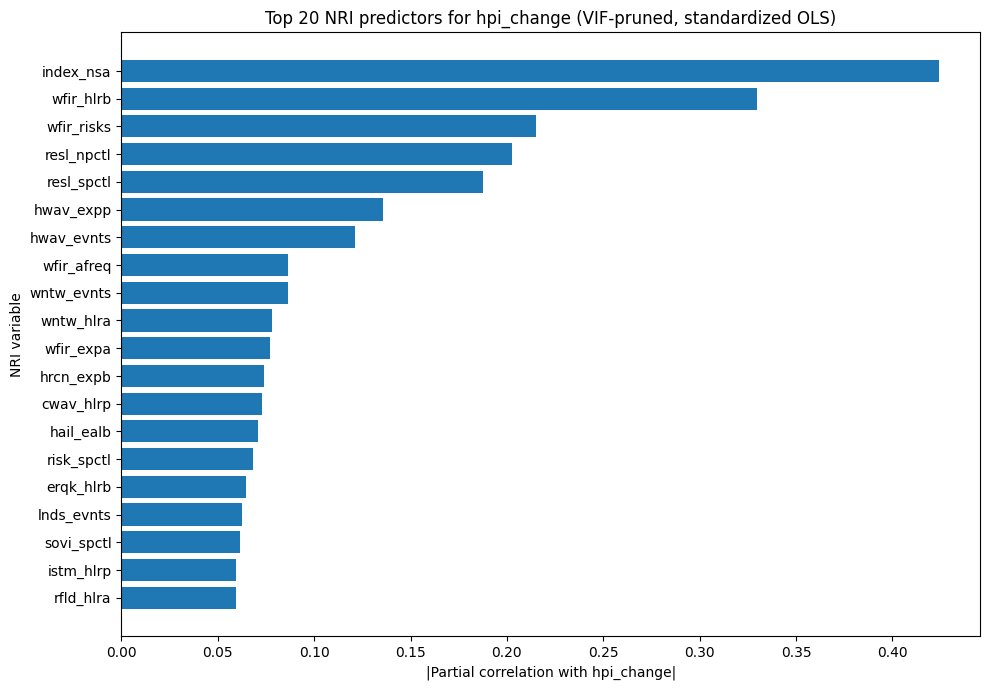

In [18]:
# ----------------------------
# 8) Save diagnostics + Top-20 plot
# ----------------------------
topN = effects.head(20)[["variable","abs_partial_r"]]
plt.figure(figsize=(10, 7))
plt.barh(topN["variable"][::-1], topN["abs_partial_r"][::-1])
plt.xlabel("|Partial correlation with hpi_change|")
plt.ylabel("NRI variable")
plt.title("Top 20 NRI predictors for hpi_change (VIF-pruned, standardized OLS)")
plt.tight_layout()

